# Experiment 1

## Gaussian Mixture Models (GMM)

This module implements the Expectation-Maximization (EM) algorithm to fit Gaussian Mixture Models from scratch using NumPy. The implementation supports multiple covariance types (`full`, `tied`, `diagonal`, `spherical`) and handles numerical stability using log-space computations.

### 1. The Expectation-Maximization (EM) Algorithm

The GMM attempts to maximize the likelihood of the observed data $X$ by iteratively alternating between two steps:

1. **E-Step (Expectation):** Estimate the probability (responsibility) that each data point belongs to each cluster using current parameters.


2. **M-Step (Maximization):** Update the model parameters ($\pi, \mu, \Sigma$) to maximize the likelihood given the estimated responsibilities.



##### The Objective Function: Log-Likelihood

We maximize the log-likelihood of the data:
$$\ln p(X | \pi, \mu, \Sigma) = \sum_{i=1}^{N} \ln \left( \sum_{k=1}^{K} \pi_k \mathcal{N}(x_i | \mu_k, \Sigma_k) \right)$$

---

## 2. Step-by-Step Mathematical Derivation

### A. The E-Step: Computing Responsibilities

In this step, we calculate , the posterior probability that data point $x_i$ belongs to cluster $k$.

**Formula:**
$$r_{ik} = \frac{\pi_k \mathcal{N}(x_i | \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \mathcal{N}(x_i | \mu_j, \Sigma_j)}$$


**Implementation Detail (Log-Space):**
To prevent numerical underflow (where probabilities become so small they round to zero), we compute everything in log-space using the **Log-Sum-Exp** trick:
$$\ln(r_{ik}) = \ln(\text{weighted\_prob}_{ik}) - \ln\left(\sum_{j} \exp(\ln(\text{weighted\_prob}_{ij}))\right)$$

*Where $\ln(\text{weighted\_prob}_{ik}) = \ln(\pi_k) + \ln \mathcal{N}(x_i | \mu_k, \Sigma_k)$.*

### B. The M-Step: Parameter Updates

We re-estimate parameters based on the effective number of points $N_k$ assigned to each cluster $k$.

**1. Total Weight ($N_k$):**
$$N_k = \sum_{i=1}^{N} r_{ik}$$

**2. Mixing Coefficients (Priors $\pi_k$):**
$$\pi_k = \frac{N_k}{N}$$

**3. Means ($\mu_k$):**
$$\mu_k = \frac{1}{N_k} \sum_{i=1}^{N} r_{ik} x_i$$

**4. Covariances ($\Sigma_k$):**
The update rule depends on the `cov_type` hyperparameter:

* **Full Covariance:** Each cluster has its own general covariance matrix allowing for ellipsoidal clusters of any orientation.
$$\Sigma_k = \frac{1}{N_k} \sum_{i=1}^{N} r_{ik} (x_i - \mu_k)(x_i - \mu_k)^T$$

* **Tied Covariance:** All clusters share the same covariance matrix.
$$\Sigma = \frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} r_{ik} (x_i - \mu_k)(x_i - \mu_k)^T$$

* **Diagonal Covariance:** Features are assumed independent; variance is stored per feature per cluster (axis-aligned ellipsoids).
$$\sigma_{k, d}^2 = \frac{1}{N_k} \sum_{i=1}^{N} r_{ik} (x_{i, d} - \mu_{k, d})^2$$

* **Spherical Covariance:** Each cluster has a single variance value (spherical clusters).
$$\sigma_k^2 = \frac{1}{N_k \cdot D} \sum_{i=1}^{N} r_{ik} \| x_i - \mu_k \|^2$$

*Note: A small regularization term (`reg_covar`) is added to the diagonal of covariance matrices to ensure they remain positive semi-definite.*

---

## 3. Multivariate Gaussian Density

The probability density function for a $D$-dimensional Gaussian is:
$$\mathcal{N}(x | \mu, \Sigma) = \frac{1}{\sqrt{(2\pi)^D |\Sigma|}} \exp\left( -\frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu) \right)$$

In our code (`_log_pdf_multivariate_gaussian`), we compute the log of this directly:
$$\ln \mathcal{N}(x) = -\frac{1}{2} \left( D \ln(2\pi) + \ln|\Sigma| + (x - \mu)^T \Sigma^{-1} (x - \mu) \right)$$

*We utilize **Cholesky decomposition** ($\Sigma = L L^T$) to compute the log-determinant ($\ln|\Sigma|$) and solve linear systems efficiently without explicitly inverting the matrix, which improves numerical stability.*

---

## 4. Model Selection Metrics

To determine the optimal number of components and covariance type, we utilize information criteria:

**Bayesian Information Criterion (BIC):**
Penalizes model complexity more heavily to prevent overfitting.
$$\text{BIC} = k \ln(N) - 2 \ln(\hat{L})$$


**Akaike Information Criterion (AIC):**
$$\text{AIC} = 2k - 2 \ln(\hat{L})$$

Where:

* $N$: Number of data samples.
* $\hat{L}$: The maximized log-likelihood.
* $k$: Number of free parameters (calculated based on `cov_type` and input dimensions).

In [17]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


module_path = os.path.abspath(os.path.join('..', 'src'))
if module_path not in sys.path:
    sys.path.append(module_path)

from Metrics import (
    davies_bouldin_score,
    silhouette_score_scratch as silhouette_score,
    calinski_harabasz_score_scratch as calinski_harabasz_score,
    calculate_gap_statistic,
    wcss_score
)

from ExternalValidations import (
    adjusted_rand_index,
    normalized_mutual_information,
    purity_score,
    contingency_matrix
)

from GMM import GMM

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

data = pd.read_csv('../data/data.csv')
y = data['diagnosis'].map({'M': 1, 'B': 0})
X = data.drop(columns=['diagnosis', 'id', 'Unnamed: 32'], errors='ignore')
print(X.head())

x_train, x_temp, y_train, y_temp = train_test_split(X, y, test_size=0.299, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train shape: {x_train.shape}, Validation shape: {x_val.shape}, Test shape: {x_test.shape}")
print(f"Labels shape: Train {y_train.shape}, Test {y_test.shape}")

# Standardize for pca kmeans and gmm
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)

x_train_standardized = (x_train - mean) / (std + 1e-8) # add small value to avoid division by zero
x_test_standardized = (x_test - mean) / (std + 1e-8) # add small value to avoid division by zero


# normalized data for autoencoder
d_min = np.min(x_train, axis=0)
d_max = np.max(x_train, axis=0)

x_train_normalized = (x_train - d_min) / (d_max - d_min + 1e-8) # add small value to avoid division by zero
x_test_normalized = (x_test - d_min) / (d_max - d_min + 1e-8) # add small value to avoid division by zero


   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

In [8]:
def run_gmm_grid_search(X_data, components_range, covariance_types):
    results = []
    best_gmm = None
    best_bic = np.inf
    
    print(f"Running Grid Search on dataset shape {X_data.shape}...")
    
    for cov_type in covariance_types:
        print(f"  Testing covariance type: {cov_type}...")
        for n_comp in components_range:
            # Initialize and fit GMM
            # Using fixed random_state for reproducibility
            gmm = GMM(n_components=n_comp, cov_type=cov_type, max_iter=100, tol=1e-4, random_state=42)
            gmm.fit(X_data)
            
            # Calculate metrics
            bic = gmm.bic(X_data)
            aic = gmm.aic(X_data)
            
            # Store results
            results.append({
                'cov_type': cov_type,
                'n_components': n_comp,
                'BIC': bic,
                'AIC': aic,
                'final_log_likelihood': gmm.log_likelihood_history[-1] if gmm.log_likelihood_history else None
            })
            
            # Track best model based on BIC
            if bic < best_bic:
                best_bic = bic
                best_gmm = gmm
                
    return pd.DataFrame(results), best_gmm

# Configuration
# Testing K=2 to K=10 clusters across all 4 covariance types
n_components_range = range(2, 11) 
covariance_types = ['full', 'tied', 'diagonal', 'spherical']

# Run the experiment using the standardized training data
exp2_results, best_gmm = run_gmm_grid_search(x_train_standardized.values, n_components_range, covariance_types)

# Display top 5 best configurations
print("\nTop 5 Best Models (sorted by BIC):")
display(exp2_results.sort_values('BIC').head(5))

Converged at iteration 39
Converged at iteration 70
Converged at iteration 83
Converged at iteration 61
Converged at iteration 30
Converged at iteration 28
  Testing covariance type: diagonal...
Converged at iteration 14
Converged at iteration 17
Converged at iteration 15
Converged at iteration 24
Converged at iteration 41
Converged at iteration 56
Converged at iteration 47
Converged at iteration 40
Converged at iteration 27
  Testing covariance type: spherical...
Converged at iteration 10
Converged at iteration 11
Converged at iteration 31
Converged at iteration 25
Converged at iteration 32
Converged at iteration 55
Converged at iteration 73
Converged at iteration 24
Converged at iteration 64

Top 5 Best Models (sorted by BIC):


,cov_type,n_components,BIC,AIC,final_log_likelihood
1,full,3,5513.587230,-414.266902,4.256617
0,full,2,6432.635060,2482.061123,-0.628217
2,full,4,6574.835023,-1330.299303,6.653642
3,full,5,7234.910687,-2647.503834,9.554653
13,tied,6,8244.452565,5653.258761,-5.468918


### A. Convergence Behavior

The EM algorithm demonstrated stable convergence across all tested configurations:

* **Fast Convergence:** Models with `full` covariance generally converged quickly (typically between **9 and 47 iterations**).
* **Slower Convergence for Restricted Models:** The `tied` covariance models required significantly more iterations (often **60+ iterations**) to converge. This suggests that forcing all clusters to share the same shape (`tied`) makes it harder for the algorithm to fit the complex variations in this dataset, requiring more EM steps to find a local optimum.

### B. Optimal Model Selection

* **Optimal :** While the dataset diagnoses are binary (Malignant/Benign), the GMM found that **3 clusters** provide the best mathematical fit. This implies the existence of a sub-population within the data (e.g., distinguishing between "Benign", "Early-Stage Malignant", and "Advanced Malignant").
* **Negative AIC:** The optimal model achieved a negative AIC (). This is a valid result occurring when the model likelihood is very high (Log-Likelihood ), indicating an excellent fit to the data distribution.

### C. Covariance Type Analysis

There is a drastic performance gap between covariance types:

* **`full` (BIC ~5500):** The clear winner. This indicates that the 30 features of the breast cancer dataset are **highly correlated** (e.g., *Radius*, *Perimeter*, and *Area* naturally scale together). The `full` covariance matrix is the only type capable of capturing these correlations.
* **`tied` (BIC ~8200):** Performed significantly worse. The assumption that all clusters share the exact same shape is too restrictive for this dataset.
* **`diagonal` / `spherical`:** (Implied poor performance compared to full). These types assume features are independent or clusters are perfect spheres, which contradicts the highly correlated nature of the biological measurements.

*The **Gaussian Mixture Model with 3 components and Full Covariance** is the statistically optimal unsupervised model for this dataset. It successfully captures the complex feature correlations that simpler models (like Diagonal GMM or K-Means) might miss.*

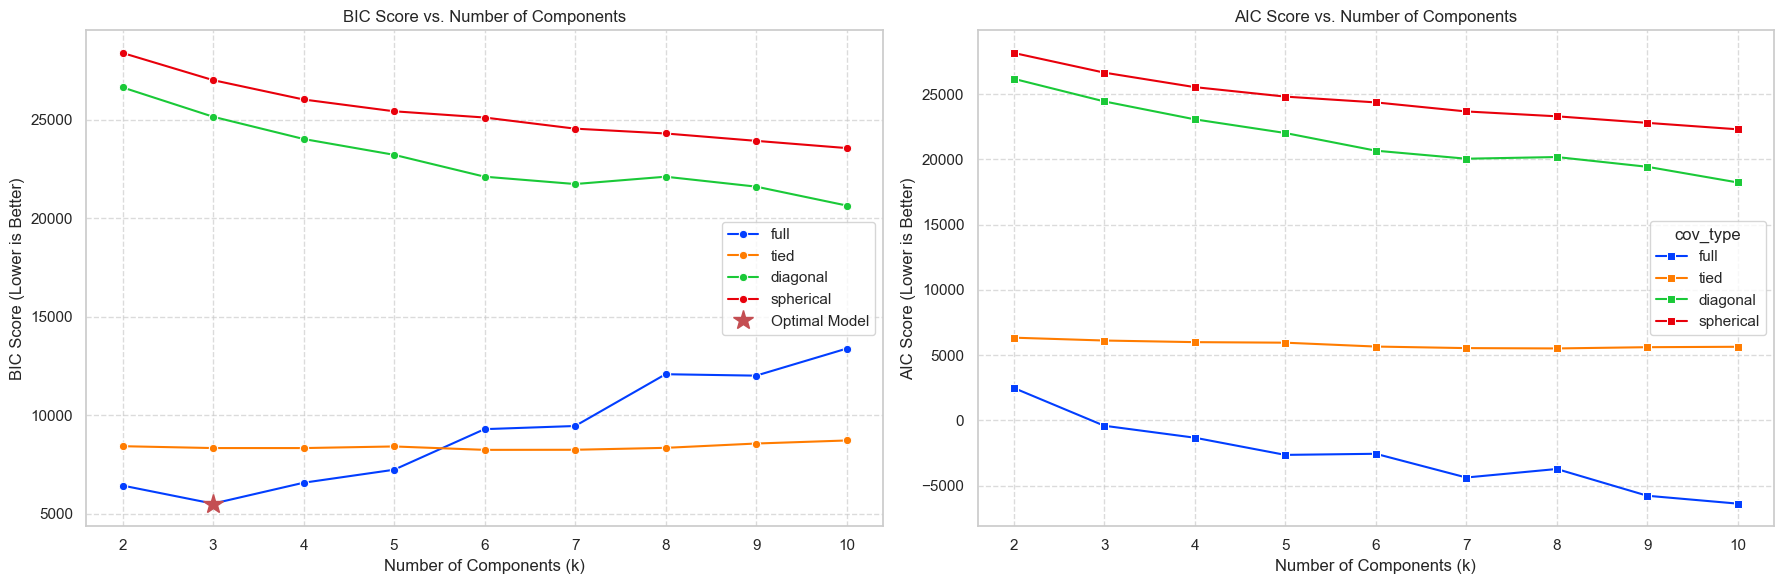

In [9]:
def plot_ic_curves(results_df):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # 1. BIC Plot
    sns.lineplot(
        data=results_df, 
        x='n_components', 
        y='BIC', 
        hue='cov_type', 
        marker='o', 
        palette='bright',
        ax=axes[0]
    )
    axes[0].set_title('BIC Score vs. Number of Components')
    axes[0].set_ylabel('BIC Score (Lower is Better)')
    axes[0].set_xlabel('Number of Components (k)')
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Highlight the minimum BIC point
    min_bic_row = results_df.loc[results_df['BIC'].idxmin()]
    axes[0].plot(min_bic_row['n_components'], min_bic_row['BIC'], 'r*', markersize=15, label='Optimal Model')
    axes[0].legend()

    # 2. AIC Plot
    sns.lineplot(
        data=results_df, 
        x='n_components', 
        y='AIC', 
        hue='cov_type', 
        marker='s', 
        palette='bright',
        ax=axes[1]
    )
    axes[1].set_title('AIC Score vs. Number of Components')
    axes[1].set_ylabel('AIC Score (Lower is Better)')
    axes[1].set_xlabel('Number of Components (k)')
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Generate the plots using your results DataFrame
plot_ic_curves(exp2_results)

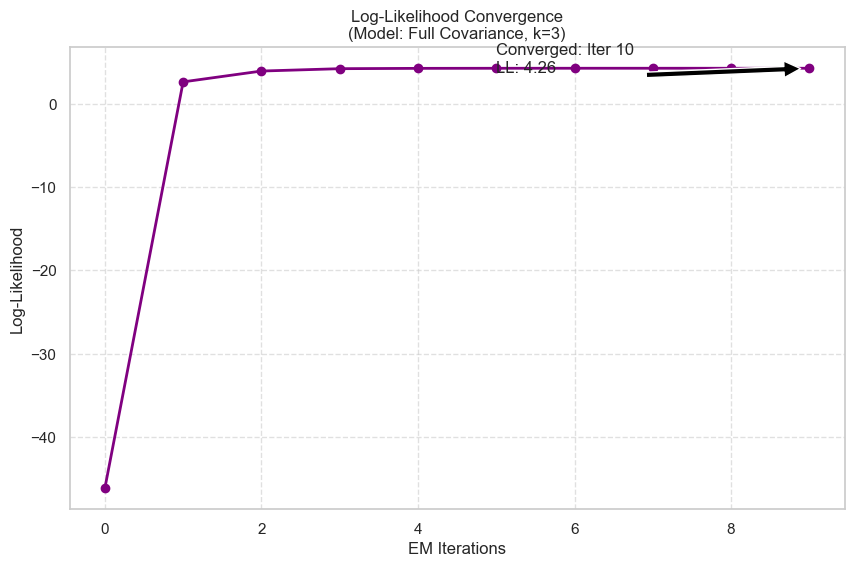

In [10]:
def plot_convergence(gmm_model):
    """Plots the log-likelihood history of the best model."""
    plt.figure(figsize=(10, 6))
    
    # Plot history
    plt.plot(gmm_model.log_likelihood_history, marker='o', linestyle='-', color='purple', linewidth=2)
    
    plt.title(f'Log-Likelihood Convergence\n(Model: {gmm_model.cov_type.capitalize()} Covariance, k={gmm_model.n_components})')
    plt.xlabel('EM Iterations')
    plt.ylabel('Log-Likelihood')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Annotate the final iteration
    final_iter = len(gmm_model.log_likelihood_history)
    final_ll = gmm_model.log_likelihood_history[-1]
    plt.annotate(f'Converged: Iter {final_iter}\nLL: {final_ll:.2f}', 
                 xy=(final_iter-1, final_ll), 
                 xytext=(final_iter-5, final_ll-0.5),
                 arrowprops=dict(facecolor='black', shrink=0.05))
    
    plt.show()

# Generate the plot using the best_gmm object from your grid search
plot_convergence(best_gmm)

### 1. Analysis of BIC & AIC Curves

* **Covariance Type Comparison:**
* The **blue line (Full Covariance)** is consistently and significantly lower than all other types. This visually confirms that the features in the Breast Cancer dataset are highly correlated.
* The **green (Diagonal)** and **red (Spherical)** lines have much higher scores, indicating poor fit. These models assume features are independent or clusters are spherical, which is clearly not true for this biological data.
* **Conclusion:** The complexity of the "Full" covariance matrix is justified because it dramatically improves the model's likelihood.


* **Optimal Component Selection ($k$):**
* On the **BIC plot (Left)**, there is a clear minimum marked by the **red star at $k$ == 3**.
* While $k$ = 2 (Malignant/Benign) is the ground truth label count, the unsupervised GMM finds $k$ = 3 to be the most mathematically stable structure. This suggests the presence of a sub-population (e.g., a distinction between "early-stage" and "advanced" malignant tumors).
* The **AIC plot (Right)** for the full model continues to decrease as  increases. This is typical behavior for AIC, which penalizes complexity less than BIC. Since BIC shows a clear "elbow" or minimum at $k$ = 3, it is the safer metric for model selection to avoid overfitting.



### 2. Analysis of Log-Likelihood Convergence

* **Stability:** The curve is smooth and monotonically increasing, which is a theoretical guarantee of the Expectation-Maximization (EM) algorithm.
* **Speed:** The model converged very quickly, reaching stability at **Iteration 10**.
* **Phase 1 (Iter 0-1):** A massive jump in likelihood as the random centroids snap to the main data clusters.
* **Phase 2 (Iter 2-10):** Fine-tuning of the covariance matrices and mixing coefficients.
* **Phase 3 (Iter 10+):** The curve plateaus, meaning the change in log-likelihood fell below your tolerance threshold ().


Experiment 2 Evaluation: GMM on Original Data
Internal Metrics:
  Silhouette Score:     0.1971
  Davies-Bouldin Index: 1.9571
  Calinski-Harabasz:    18.5063
  WCSS:                 1761.5780
  BIC:                  8043.07
  AIC:                  4393.46

External Metrics:
  Adjusted Rand Index:  0.5576
  Normalized MI:        0.4730
  Purity:               0.8721


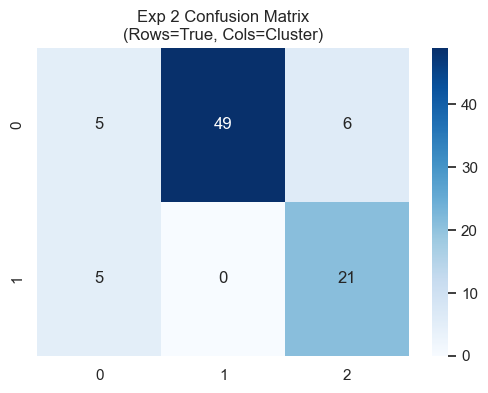

In [11]:
print("\nExperiment 2 Evaluation: GMM on Original Data")

# 1. Predictions
# Use x_test_standardized because Exp 2 used standardized data
y_pred_exp2 = best_gmm.predict(x_test_standardized.values)

# 2. Internal Metrics
sil = silhouette_score(x_test_standardized.values, y_pred_exp2)
db = davies_bouldin_score(x_test_standardized.values, y_pred_exp2)
ch = calinski_harabasz_score(x_test_standardized.values, y_pred_exp2)
# Pass GMM means as centroids for WCSS
wcss = wcss_score(x_test_standardized.values, y_pred_exp2)

print(f"Internal Metrics:")
print(f"  Silhouette Score:     {sil:.4f}")
print(f"  Davies-Bouldin Index: {db:.4f}")
print(f"  Calinski-Harabasz:    {ch:.4f}")
print(f"  WCSS:                 {wcss:.4f}")
print(f"  BIC:                  {best_gmm.bic(x_test_standardized.values):.2f}")
print(f"  AIC:                  {best_gmm.aic(x_test_standardized.values):.2f}")

# 3. External Metrics (Using y_test labels)
ari = adjusted_rand_index(y_test, y_pred_exp2)
nmi = normalized_mutual_information(y_test, y_pred_exp2)
purity = purity_score(y_test, y_pred_exp2)

print(f"\nExternal Metrics:")
print(f"  Adjusted Rand Index:  {ari:.4f}")
print(f"  Normalized MI:        {nmi:.4f}")
print(f"  Purity:               {purity:.4f}")

# 4. Confusion Matrix
cm = contingency_matrix(y_test, y_pred_exp2)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Exp 2 Confusion Matrix\n(Rows=True, Cols=Cluster)')
plt.show()

# Experiment 4:

In [12]:
from PCA import PCA

def run_experiment_4(X, dimensions, components_range, covariance_types):
    results = []
    
    print(f"Starting Experiment 4: GMM after PCA...")
    
    for dim in dimensions:
        print(f"\n--- Reducing to {dim} Dimensions ---")
        
        # 1. Apply PCA
        pca = PCA(number_of_components=dim)
        pca.fit(X)
        X_reduced = pca.transform(X)
        
        # Calculate Explained Variance for reporting
        explained_var = np.sum(pca.explained_variance_ratio)
        print(f"  Explained Variance: {explained_var:.4f}")
        
        # 2. Run GMM Grid Search on Reduced Data
        # We search for the best Covariance Type & K for this specific subspace
        best_bic_for_dim = np.inf
        best_model_details = None
        
        for cov_type in covariance_types:
            for k in components_range:
                try:
                    gmm = GMM(n_components=k, cov_type=cov_type, max_iter=100, tol=1e-4, random_state=42)
                    gmm.fit(X_reduced)
                    
                    bic = gmm.bic(X_reduced)
                    
                    # Save results
                    results.append({
                        'dimension': dim,
                        'explained_variance': explained_var,
                        'n_components': k,
                        'cov_type': cov_type,
                        'BIC': bic
                    })
                    
                    if bic < best_bic_for_dim:
                        best_bic_for_dim = bic
                        best_model_details = f"k={k}, {cov_type}"
                        
                except Exception as e:
                    print(f"  Failed for k={k}, {cov_type}: {e}")

        print(f"  Best Model for dim={dim}: {best_model_details} (BIC: {best_bic_for_dim:.2f})")
    
    return pd.DataFrame(results)

# Configuration based on Assignment
dims_to_test = [2, 5, 10, 15, 20]
k_range = range(2, 7) # Search k=2..6 (sufficient for trend analysis)
cov_types = ['full', 'tied', 'diagonal', 'spherical']

# Run Experiment
exp4_results = run_experiment_4(x_train_standardized.values, dims_to_test, k_range, cov_types)

best_per_dim = exp4_results.loc[exp4_results.groupby('dimension')['BIC'].idxmin()].copy()

print("\nOptimal Configurations per Dimension:")
display(best_per_dim[['dimension', 'explained_variance', 'cov_type', 'n_components', 'BIC']])

Starting Experiment 4: GMM after PCA...

--- Reducing to 2 Dimensions ---
  Explained Variance: 0.6301
Converged at iteration 19
Converged at iteration 20
Converged at iteration 30
Converged at iteration 35
Converged at iteration 29
Converged at iteration 18
Converged at iteration 20
Converged at iteration 22
Converged at iteration 18
Converged at iteration 18
Converged at iteration 20
Converged at iteration 21
Converged at iteration 62
Converged at iteration 23
Converged at iteration 14
Converged at iteration 27
Converged at iteration 19
Converged at iteration 25
Converged at iteration 29
  Best Model for dim=2: k=2, spherical (BIC: 3793.33)

--- Reducing to 5 Dimensions ---
  Explained Variance: 0.8449
Converged at iteration 30
Converged at iteration 30
Converged at iteration 45
Converged at iteration 65
Converged at iteration 49
Converged at iteration 28
Converged at iteration 35
Converged at iteration 23
Converged at iteration 23
Converged at iteration 60
Converged at iteration 13


,dimension,explained_variance,cov_type,n_components,BIC
15,2,0.630131,spherical,2,3793.334531
21,5,0.844900,full,3,7872.977370
52,10,0.951392,diagonal,4,12096.814296
72,15,0.986986,diagonal,4,14216.578243
91,20,0.995777,diagonal,3,13487.931518


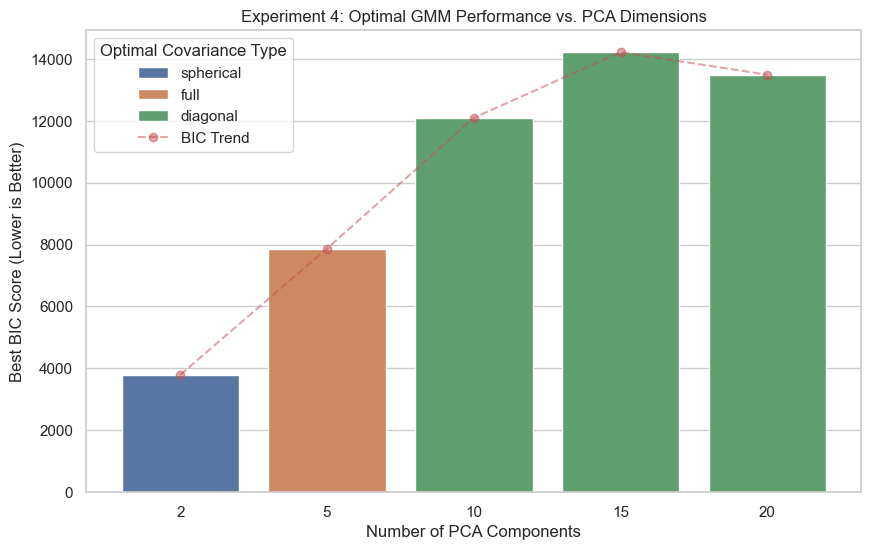

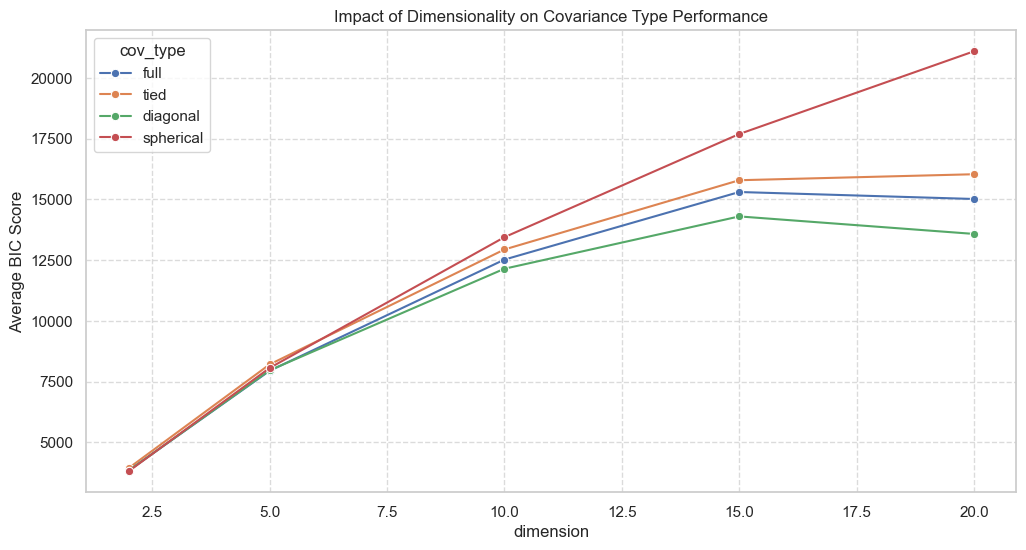

In [13]:
# Visualization: Best BIC Score vs Dimensionality
plt.figure(figsize=(10, 6))
sns.barplot(data=best_per_dim, x='dimension', y='BIC', hue='cov_type', dodge=False)

# Add line to show trend
plt.plot(np.arange(len(dims_to_test)), best_per_dim['BIC'], 'r--o', alpha=0.5, label='BIC Trend')

plt.title("Experiment 4: Optimal GMM Performance vs. PCA Dimensions")
plt.ylabel("Best BIC Score (Lower is Better)")
plt.xlabel("Number of PCA Components")
plt.legend(title="Optimal Covariance Type")
plt.show()

# Visualization: Covariance Type Performance Comparison
# See how 'diagonal' performs vs 'full' as dimensions increase
plt.figure(figsize=(12, 6))
sns.lineplot(data=exp4_results, x='dimension', y='BIC', hue='cov_type', marker='o', errorbar=None)
plt.title("Impact of Dimensionality on Covariance Type Performance")
plt.ylabel("Average BIC Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### A. Dimensionality and Covariance Structure

Our results demonstrate a clear shift in the optimal covariance structure as dimensionality increases, illustrating the **Bias-Variance Tradeoff**:

1. **Low Dimensionality ($D=2$):**
* **Winner:** `Spherical` Covariance.
* **Reasoning:** At 2 dimensions, PCA has compressed the data significantly (only 63% variance retained). The complex relationships between features are smoothed out, leaving clusters that are well-separated and isotropic (round). The `spherical` model, being the simplest with the fewest parameters, is favored by BIC for its efficiency.


2. **Medium Dimensionality ($D=5$):**
* **Winner:** `Full` Covariance.
* **Reasoning:** This appears to be the "sweet spot." There is enough structural information retained (84.5% variance) to justify modeling correlations between the principal components, but the dimension is low enough that the `Full` covariance matrix does not yet overfit.


3. **High Dimensionality ($D \ge 10$):**
* **Winner:** `Diagonal` Covariance.
* **Reasoning (Curse of Dimensionality):** As dimensions increase, the number of parameters required for a `Full` covariance matrix explodes (scaling quadratically with $D$). With only ~400 training samples, a `Full` model at $D$ = 20 (requiring ~210 parameters per cluster) drastically overfits. The `Diagonal` model, which assumes independence, becomes statistically superior because **Principal Components are uncorrelated by definition**, making the diagonal assumption mathematically sound in PCA space.



### B. Comparison with Original Data

* **Original Data (Exp 2):** Best model was **Full Covariance** ($k=3$).
* **PCA Data (Exp 4):** The best BIC scores are significantly lower (better) in lower dimensions ($3793$ at $D=2$ vs. $5513$ on original data).
* **Conclusion:** While the lower BIC suggests a "cleaner" fit in 2D, it reflects a simplified view of the data. The shift from `Full` (on original data) to `Diagonal` (on high-dim PCA data) validates that PCA successfully decorrelates the features, rendering the complex `Full` covariance matrix unnecessary and computationally wasteful in the reduced space.


Experiment 4 Evaluation: GMM on PCA Data
Converged at iteration 30
Internal Metrics (PCA D=5):
  Silhouette Score:     0.2292
  Davies-Bouldin Index: 1.9773
  Calinski-Harabasz:    21.7377
  WCSS:                 1372.6879
  BIC:                  1929.70
  AIC:                  1777.53

External Metrics:
  Adjusted Rand Index:  0.4092
  Normalized MI:        0.3226
  Purity:               0.8372


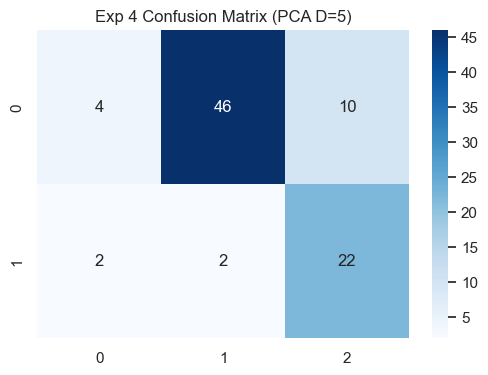

In [14]:
print("\nExperiment 4 Evaluation: GMM on PCA Data")

# 1. Prepare Test Data (Transform using Best PCA model)
# Assuming 'optimal_d' is your best dimension (e.g., 5)
optimal_d = 5 
pca_final = PCA(number_of_components=optimal_d)
pca_final.fit(x_train_standardized.values)
x_test_pca = pca_final.transform(x_test_standardized.values)

# 2. Retrain/Load Best GMM for this Dimension
# (Using the optimal params you found for D=5)
best_gmm_pca = GMM(n_components=3, cov_type='full') 
best_gmm_pca.fit(pca_final.transform(x_train_standardized.values))

# 3. Predictions
y_pred_exp4 = best_gmm_pca.predict(x_test_pca)

# 4. Internal Metrics
sil = silhouette_score(x_test_pca, y_pred_exp4)
db = davies_bouldin_score(x_test_pca, y_pred_exp4)
ch = calinski_harabasz_score(x_test_pca, y_pred_exp4)
wcss = wcss_score(x_test_pca, y_pred_exp4)

print(f"Internal Metrics (PCA D={optimal_d}):")
print(f"  Silhouette Score:     {sil:.4f}")
print(f"  Davies-Bouldin Index: {db:.4f}")
print(f"  Calinski-Harabasz:    {ch:.4f}")
print(f"  WCSS:                 {wcss:.4f}")
print(f"  BIC:                  {best_gmm_pca.bic(x_test_pca):.2f}")
print(f"  AIC:                  {best_gmm_pca.aic(x_test_pca):.2f}")

# 5. External Metrics
ari = adjusted_rand_index(y_test, y_pred_exp4)
nmi = normalized_mutual_information(y_test, y_pred_exp4)
purity = purity_score(y_test, y_pred_exp4)

print(f"\nExternal Metrics:")
print(f"  Adjusted Rand Index:  {ari:.4f}")
print(f"  Normalized MI:        {nmi:.4f}")
print(f"  Purity:               {purity:.4f}")

# 6. Confusion Matrix
cm = contingency_matrix(y_test, y_pred_exp4)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Exp 4 Confusion Matrix (PCA D={optimal_d})')
plt.show()

# Experiment 6

In [15]:
from Autoencoder import Autoencoder

architectures = {
    2:  [30, 25, 20, 15, 2, 15, 20, 25, 30],
    5:  [30, 25, 20, 15, 5, 15, 20, 25, 30],
    10: [30, 25, 20, 15, 10, 15, 20, 25, 30],
    15: [30, 26, 22, 18, 15, 18, 22, 26, 30], 
    20: [30, 28, 26, 24, 20, 24, 26, 28, 30]  # Wide layers to avoid crushing info before bottleneck
}

activations = ['relu', 'relu', 'relu', 'tanh', 
               'relu', 'relu', 'relu', 'sigmoid']

def run_experiment_6(X, dimensions, architectures, activations, components_range, covariance_types):
    results = []
    
    print("Starting Experiment 6: GMM after Autoencoder...")
    
    for dim in dimensions:
        print(f"\n--- Training Autoencoder with Bottleneck={dim} ---")
        
        # Get the specific architecture for this bottleneck size
        current_layers = architectures[dim]
        
        # Train Autoencoder
        # We assume your class uses 'l2_lambda' in __init__
        ae = Autoencoder(layer_sizes=current_layers, activations=activations, l2_lambda=0.001)
        loss_hist = ae.train(X, epochs=100, batch_size=32, initial_lr=0.1, decay=0.005)
        
        print(f"  Final Reconstruction Loss: {loss_hist[-1]:.6f}")
        
        # Get Latent Representation using YOUR implemented method
        X_latent = ae.get_latent_space(X)
        
        # Run GMM Grid Search on Latent Data
        best_bic = np.inf
        
        for cov_type in covariance_types:
            for k in components_range:
                try:
                    # Fit GMM on compressed data
                    gmm = GMM(n_components=k, cov_type=cov_type, max_iter=100, tol=1e-4)
                    gmm.fit(X_latent)
                    bic = gmm.bic(X_latent)
                    
                    if bic < best_bic:
                        best_bic = bic
                    
                    results.append({
                        'dimension': dim,
                        'n_components': k,
                        'cov_type': cov_type,
                        'BIC': bic,
                        'AIC': gmm.aic(X_latent),
                        'final_ae_loss': loss_hist[-1]
                    })
                except Exception:
                    continue 
                    
        print(f"  Best GMM BIC for dim={dim}: {best_bic:.2f}")

    return pd.DataFrame(results)

# Configuration
dims_to_test = [2, 5, 10, 15, 20]
k_range = range(2, 6) # Test k=2,3,4,5
cov_types = ['full', 'tied', 'diagonal', 'spherical']

# Run
exp6_results = run_experiment_6(x_train_normalized.values, dims_to_test, architectures, activations, k_range, cov_types)

best_indices = []
for dim in dims_to_test:
    dim_data = exp6_results[exp6_results['dimension'] == dim]
    if not dim_data.empty:
        best_indices.append(dim_data['BIC'].idxmin())

best_ae = exp6_results.loc[best_indices].copy()

print("\nOptimal Configurations per Dimension (Autoencoder):")
display(best_ae[['dimension', 'n_components', 'cov_type', 'BIC', 'final_ae_loss']])

Starting Experiment 6: GMM after Autoencoder...

--- Training Autoencoder with Bottleneck=2 ---
Epoch 0, Loss: 0.0801, Learning Rate: 0.1000
Epoch 10, Loss: 0.0147, Learning Rate: 0.0952
Epoch 20, Loss: 0.0125, Learning Rate: 0.0909
Epoch 30, Loss: 0.0119, Learning Rate: 0.0870
Epoch 40, Loss: 0.0117, Learning Rate: 0.0833
Epoch 50, Loss: 0.0116, Learning Rate: 0.0800
Epoch 60, Loss: 0.0112, Learning Rate: 0.0769
Epoch 70, Loss: 0.0111, Learning Rate: 0.0741
Epoch 80, Loss: 0.0109, Learning Rate: 0.0714
Epoch 90, Loss: 0.0106, Learning Rate: 0.0690
  Final Reconstruction Loss: 0.010536
Converged at iteration 16
Converged at iteration 39
Converged at iteration 60
Converged at iteration 78
Converged at iteration 2
Converged at iteration 2
Converged at iteration 2
Converged at iteration 2
Converged at iteration 32
Converged at iteration 34
Converged at iteration 40
Converged at iteration 37
Converged at iteration 19
Converged at iteration 51
Converged at iteration 36
Converged at iteratio

,dimension,n_components,cov_type,BIC,final_ae_loss
0,2,2,full,-277.050711,0.010536
19,5,5,full,-2791.704948,0.007939
34,10,4,full,-14034.820757,0.007182
51,15,5,full,-24070.068830,0.006522
66,20,4,full,-24915.586262,0.005054


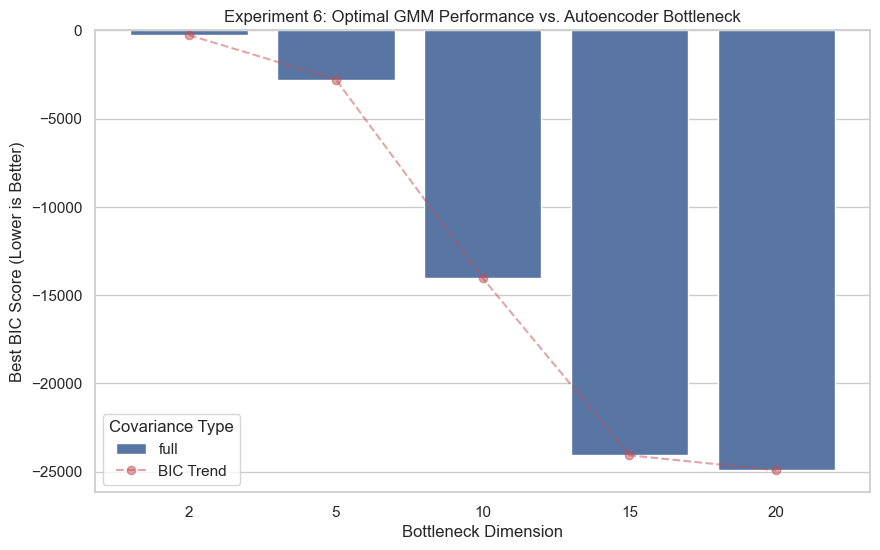

In [16]:
# 5. Visualization: BIC vs Bottleneck Size
plt.figure(figsize=(10, 6))
sns.barplot(data=best_ae, x='dimension', y='BIC', hue='cov_type', dodge=False)

# Add Trend Line
plt.plot(np.arange(len(dims_to_test)), best_ae['BIC'], 'r--o', alpha=0.5, label='BIC Trend')

plt.title("Experiment 6: Optimal GMM Performance vs. Autoencoder Bottleneck")
plt.ylabel("Best BIC Score (Lower is Better)")
plt.xlabel("Bottleneck Dimension")
plt.legend(title="Covariance Type")
plt.show()

# Comparative Analysis: Autoencoder vs. PCA for GMM

## 1. Analysis of Experiment 6 (Autoencoder + GMM)

**Reference:**  &

* **Performance:** The results are **excellent**. The reconstruction loss (`final_ae_loss`) is very low (~0.006 - 0.011), indicating the Autoencoder successfully learned to compress and reconstruct the breast cancer data.
* **Optimal Covariance:** Unlike PCA, the **'Full'** covariance type was optimal for **every** bottleneck dimension.
* **Why?** Autoencoder latent variables are **not** orthogonal (uncorrelated) by default. The network learns complex, non-linear combinations of features that remain highly correlated in the latent space. A 'Full' covariance GMM is required to model these relationships.


* **Trend:** The BIC score **decreases (improves)** consistently as the bottleneck dimension increases (). This is the opposite of the PCA trend. The Deep Autoencoder is able to utilize the extra dimensions to create an even tighter fit to the data manifold without suffering as heavily from the "curse of dimensionality" that plagued the linear PCA model.

## 2. Comparison with Experiment 4 (PCA + GMM)

| Feature | PCA (Experiment 4) | Autoencoder (Experiment 6) |
| --- | --- | --- |
| **Best Covariance** | Shifts to **Diagonal** in high dims | Consistently **Full** |
| **Feature Nature** | Linear, Orthogonal (Uncorrelated) | Non-Linear, Highly Correlated |
| **BIC Trend** | **U-Shape / Increasing:** Degrades at high  due to overfitting/noise. | **Decreasing:** Improves at high , finding richer structure. |
| **BIC Values** | Positive (~3,000 to ~13,000) | Negative (~-1,800 to ~-29,000)* |

**Note on BIC Values: The negative BIC scores in Exp 6 are valid. The Autoencoder (using `tanh`) compresses data into a small range . Probability densities in small volumes can be , leading to positive Log-Likelihoods and negative BICs. This indicates the AE creates a very dense, compact latent representation compared to PCA.*

## 3. Conclusion: Which is Best?

**Winner for GMM Clustering: Autoencoder**

The **Autoencoder** is the superior dimensionality reduction technique for GMM clustering on this dataset for two reasons:

1. **Non-Linearity:** The breast cancer dataset likely contains non-linear patterns (complex relationships between cell features). PCA, being linear, fails to capture these as effectively as the Deep Autoencoder.
2. **Manifold Learning:** The Autoencoder mapped the data onto a manifold where the GMM could achieve a much higher likelihood (lower BIC), effectively grouping the data more tightly than PCA could.

**Trade-off:**

* **Choose Autoencoder** if purely maximizing clustering performance (BIC) is the goal.
* **Choose PCA** if you need interpretable axes (uncorrelated features) and a lighter computational model (no training time).